In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
data_dir = '/content/drive/MyDrive/AI_model/src/processed_data'

X_train = joblib.load(
    f'{data_dir}/X_train.pkl'
)

X_val = joblib.load(
    f'{data_dir}/X_val.pkl'
)

y_train = joblib.load(
    f'{data_dir}/y_train.pkl'
)

y_val = joblib.load(
    f'{data_dir}/y_val.pkl'
)

In [6]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1600, 20)
X_val: (400, 20)
y_train: (1600,)
y_val: (400,)


In [7]:
model_dir = '/content/drive/MyDrive/AI_model/model'

In [9]:
models = {
    'Logistic Regression': joblib.load(
        f'{model_dir}/logistic_regression.pkl'
    ),

    'KNN': joblib.load(
        f'{model_dir}/knn.pkl'
    )
}

In [10]:
results = []

predictions = {}

for name, model in models.items():

    y_pred = model.predict(X_val)

    predictions[name] = y_pred

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_val,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average='weighted'
    )

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

In [11]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1-score',
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.975,0.975946,0.975,0.975020
1,KNN,0.530,0.569762,0.530,0.540707


In [12]:
results_df.to_csv(
    f'{data_dir}/evaluation_results.csv',
    index=False
)

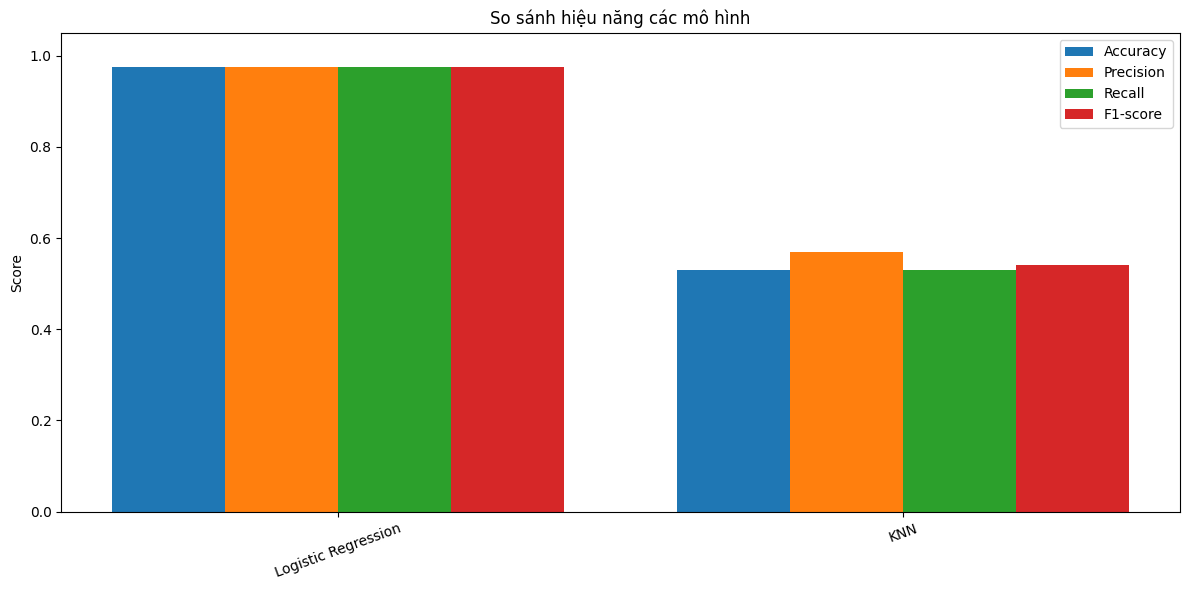

In [13]:
plt.figure(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

plt.bar(
    x - 1.5 * width,
    results_df['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x - 0.5 * width,
    results_df['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x + 0.5 * width,
    results_df['Recall'],
    width,
    label='Recall'
)

plt.bar(
    x + 1.5 * width,
    results_df['F1-score'],
    width,
    label='F1-score'
)

plt.xticks(
    x,
    results_df['Model'],
    rotation=20
)

plt.ylabel('Score')
plt.title('So sánh hiệu năng các mô hình')

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()

plt.show()

In [14]:
eval_dir = '/content/drive/MyDrive/hocMay/figure/evaluation'

os.makedirs(
    eval_dir,
    exist_ok=True
)

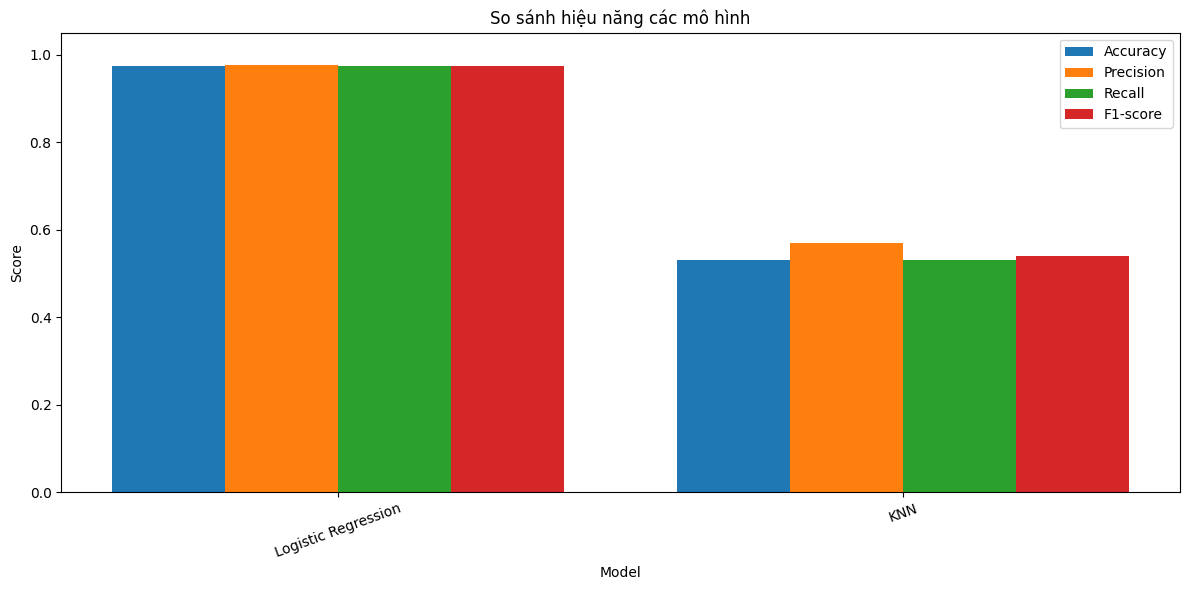

In [15]:
plt.figure(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.2

plt.bar(
    x - 1.5 * width,
    results_df['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x - 0.5 * width,
    results_df['Precision'],
    width,
    label='Precision'
)

plt.bar(
    x + 0.5 * width,
    results_df['Recall'],
    width,
    label='Recall'
)

plt.bar(
    x + 1.5 * width,
    results_df['F1-score'],
    width,
    label='F1-score'
)

plt.xticks(
    x,
    results_df['Model'],
    rotation=20
)

plt.ylabel('Score')
plt.xlabel('Model')

plt.title(
    'So sánh hiệu năng các mô hình'
)

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()

plt.savefig(
    f'{eval_dir}/model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close()

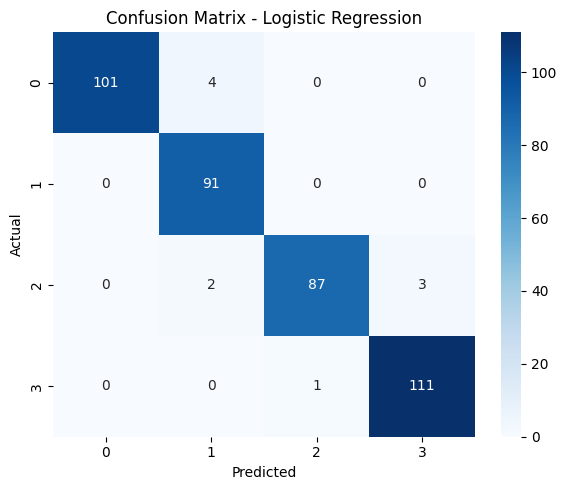

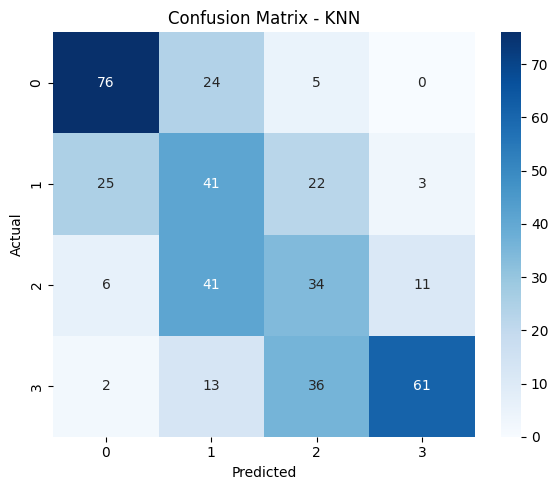

In [16]:
for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_val,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[0, 1, 2, 3],
        yticklabels=[0, 1, 2, 3]
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.title(
        f'Confusion Matrix - {name}'
    )

    plt.tight_layout()

    filename = (
        name.lower()
        .replace(' ', '_')
        + '_confusion_matrix.png'
    )

    plt.savefig(
        f'{eval_dir}/{filename}',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

In [17]:
for name, y_pred in predictions.items():

    print('=' * 70)
    print(name)
    print('=' * 70)

    print(
        classification_report(
            y_val,
            y_pred,
            target_names=[
                'Price 0',
                'Price 1',
                'Price 2',
                'Price 3'
            ]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

     Price 0       1.00      0.96      0.98       105
     Price 1       0.94      1.00      0.97        91
     Price 2       0.99      0.95      0.97        92
     Price 3       0.97      0.99      0.98       112

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.98       400

KNN
              precision    recall  f1-score   support

     Price 0       0.70      0.72      0.71       105
     Price 1       0.34      0.45      0.39        91
     Price 2       0.35      0.37      0.36        92
     Price 3       0.81      0.54      0.65       112

    accuracy                           0.53       400
   macro avg       0.55      0.52      0.53       400
weighted avg       0.57      0.53      0.54       400



In [18]:
best_score = results_df.iloc[0]['F1-score']

print(
    f"F1-score: {best_score:.4f}"
)

F1-score: 0.9750
